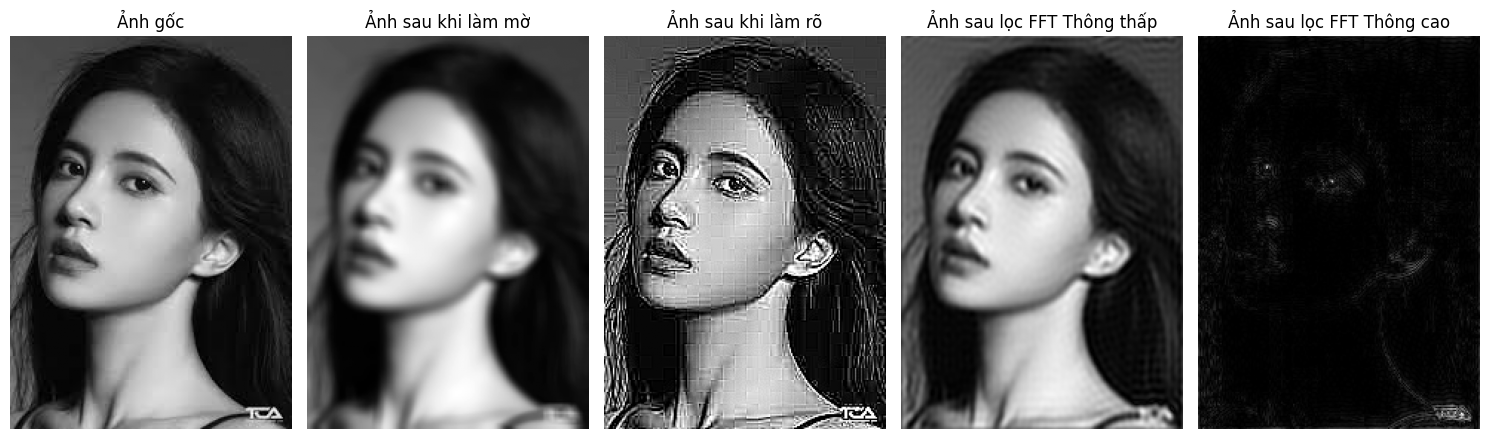

ĐÁNH GIÁ CHẤT LƯỢNG ẢNH SAU KHI LỌC
Lọc thông thấp        PSNR=   26.80 dB | SSIM=0.8460
Lọc thông cao         PSNR=   18.45 dB | SSIM=0.5754
Lọc thông thấp (FFT)  PSNR=   25.25 dB | SSIM=0.8893
Lọc thông cao (FFT)   PSNR=    7.53 dB | SSIM=0.1221


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt     
from skimage.metrics import structural_similarity as ssim
from pathlib import Path
import sys

# uploaded=files.upload()                  
# for file_name in uploaded.keys():
#     print("Đã tải:", file_name)

# Nhập từ bàn phím:
IMAGE_PATH = Path(input("Nhập đường dẫn ảnh: ").strip())
file_name = str(IMAGE_PATH)

# KIỂM TRA: chỉ nhận ảnh đen trắng (grayscale). Nếu ảnh màu -> báo lỗi và thoát.
img_color_probe = cv2.imread(file_name, cv2.IMREAD_COLOR)
if img_color_probe is None:
    print("Lỗi: không tìm thấy ảnh")
    sys.exit(1)
if img_color_probe.ndim == 3 and img_color_probe.shape[2] >= 3:
    b, g, r = cv2.split(img_color_probe)
    if not (np.array_equal(b, g) and np.array_equal(g, r)):
        print("Lỗi: chỉ nhận ảnh đen trắng (grayscale). Đường dẫn hiện đang trỏ tới ảnh màu.")
        sys.exit(1)

# Đọc dữ liệu (đọc ảnh xám)
img = cv2.imread(file_name, cv2.IMREAD_GRAYSCALE)
if img is None:
  print("Lỗi: không tìm thấy ảnh")
  sys.exit(1)

# DÙNG BỘ LỌC
# Làm mờ
blur = cv2.blur(img, (7,7))
# Làm rõ
kernel = np.array([[-1,-1,-1],
                   [-1, 9,-1],
                   [-1,-1,-1]]) #tạo mặt nạ
sharpened = cv2.filter2D(img, -1, kernel) #lấy tích chập

# DÙNG FFT
# Lọc thông thấp trong miền tần số (FFT)

# BỔ SUNG: FFT CHỈ NHẬN ẢNH ĐEN TRẮNG 2D
def _ensure_grayscale_2d(channel, name="Ảnh"):
    if channel is None:
        raise ValueError(f"{name}: dữ liệu rỗng.")
    if channel.ndim != 2:
        raise ValueError(f"{name}: chỉ chấp nhận ảnh đen trắng (2D).")

f = np.fft.fft2(img) #biến đổi fourier cho ảnh xám 2D
fshift = np.fft.fftshift(f) #dịch tâm phổ để tần số thắp nằm giữa, tần số cao nằm ở góc
rows, cols = img.shape

def fft_lowpass(channel, radius=40):
    _ensure_grayscale_2d(channel, "FFT Low-pass")
    f = np.fft.fft2(channel)                 # biến đổi fourier cho ảnh xám 2D
    fshift = np.fft.fftshift(f)              # dịch tâm phổ: tần số thấp ở giữa
    rows, cols = channel.shape
    crow, ccol = rows // 2, cols // 2        # tọa độ tâm phổ
    mask = np.zeros((rows, cols), np.uint8)  # mask cùng kích thước ảnh
    cv2.circle(mask, (ccol, crow), radius, 1, -1)  # lấy toàn bộ phía trong (low-pass)
    fshift_lp = fshift * mask                # nhân từng phần tử
    img_back = np.abs(np.fft.ifft2(np.fft.ifftshift(fshift_lp)))  # về miền không gian
    img_back = cv2.normalize(img_back, None, 0, 255, cv2.NORM_MINMAX)  # chuẩn hóa
    return img_back.astype(np.uint8)

img_low = fft_lowpass(img, radius=40) #lọc kênh xám

def fft_highpass(channel, radius=40):
    _ensure_grayscale_2d(channel, "FFT High-pass")
    f = np.fft.fft2(channel)
    fshift = np.fft.fftshift(f)
    rows, cols = channel.shape
    crow, ccol = rows // 2, cols // 2
    mask = np.ones((rows, cols), np.uint8)
    cv2.circle(mask, (ccol, crow), radius, 0, -1)  # lấy phần bên ngoài (high-pass)
    fshift_hp = fshift * mask
    img_back = np.abs(np.fft.ifft2(np.fft.ifftshift(fshift_hp)))
    img_back = cv2.normalize(img_back, None, 0, 255, cv2.NORM_MINMAX)
    return img_back.astype(np.uint8)

img_high = fft_highpass(img, radius=40)

titles = ["Ảnh gốc", "Ảnh sau khi làm mờ", "Ảnh sau khi làm rõ", "Ảnh sau lọc FFT Thông thấp", "Ảnh sau lọc FFT Thông cao"]
images = [img, blur, sharpened, img_low, img_high]
plt.figure(figsize=(15, 5))
for i in range(5):
    plt.subplot(1, 5, i+1)
    # Hiển thị ảnh xám
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i], fontsize=12)
    plt.axis('off')
plt.tight_layout()
plt.show()

# TÍNH TOÁN CHỈ SỐ CHẤT LƯỢNG
def mse(imageA, imageB):
    imageA = cv2.resize(imageA, (imageB.shape[1], imageB.shape[0]))
    err = np.mean((imageA.astype("float") - imageB.astype("float")) ** 2)
    return err

def psnr(imageA, imageB):
    mse_value = mse(imageA, imageB)
    if mse_value == 0:
        return 100
    PIXEL_MAX = 255.0
    return 20 * np.log10(PIXEL_MAX / np.sqrt(mse_value))

def ssim_index(imageA, imageB):
    #chuyển về ảnh xám
    if imageA.ndim == 3:
        imageA = cv2.cvtColor(np.uint8(imageA), cv2.COLOR_BGR2GRAY)
    if imageB.ndim == 3:
        imageB = cv2.cvtColor(np.uint8(imageB), cv2.COLOR_BGR2GRAY)
    # thêm data_range để chạy ổn định trên skimage mới
    s = ssim(imageA, imageB, data_range=255)
    return s

def evaluate(ref, test, name):
    m = mse(ref, test)
    p = psnr(ref, test)
    s = ssim_index(ref, test)
    print(f"{name:20s}  PSNR={p:8.2f} dB | SSIM={s:6.4f}")

print("ĐÁNH GIÁ CHẤT LƯỢNG ẢNH SAU KHI LỌC")
evaluate(img, blur, "Lọc thông thấp")
evaluate(img, sharpened, "Lọc thông cao")
evaluate(img, img_low, "Lọc thông thấp (FFT)")
evaluate(img, img_high, "Lọc thông cao (FFT)")